## Test on original data

#### Import Packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import builtins
from google.colab import drive

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!python3 --version

Python 3.12.12


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
import json
from joblib import Parallel, delayed
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score

warnings.filterwarnings("ignore")


Load feature engineered data.

In [ ]:
# Load column types
with open('/content/drive/My Drive/Colab Notebooks/data/data_types.json', 'r') as f:
    dtypes_dict = json.load(f)

# Read CSV with types
df_fea_eng = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/df_fea_eng.csv', dtype=dtypes_dict)

#### Data Splitting

In [ ]:
target = 'happy'

X = df_fea_eng.drop(target, axis=1)
y = df_fea_eng[target]

In [ ]:
# Step 2: train/test/val split (stratified) to correct balancing
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#### Imputation Preparation

Set up imputation pipelines for categorical and numerical data.

In [ ]:
# ---------------------------
# Column groups: ordinal, nominal, discrete, continuous
# ---------------------------
continuous_cols = ['age'] # continuous
discrete_cols = [ c for c in X.columns          # discrete variables
    if X[c].nunique() >= 10 and X[c].dtype != 'object' and c not in continuous_cols]
ordinal_cols = [ c for c in X.columns           # ordinal variables
    if X[c].dropna().nunique() <= 10 and X[c].dtype != 'object'
]
nominal_cols = list(X.select_dtypes(include='object').columns) # nominal variables

print("Continuous: ",continuous_cols)
print("Discrete: ", discrete_cols)
print("Ordinal: ", ordinal_cols)
print("Nominal: ", nominal_cols)

Continuous:  ['age']
Discrete:  ['num_of_child', 'num_of_household']
Ordinal:  ['compassion1', 'compassion2', 'compassion3', 'compassion4', 'chief_wage', 'income_scale', 'immigrant', 'mom_immigrant', 'dad_immigrant', 'religious1', 'religious2', 'religious3', 'religious4', 'dad_education_level', 'ga_leaders_male_better', 'comp_good_vs_harm', 'gov_vs_individual', 'income_eq_vs_diff', 'live_with_parent', 'marital_status', 'pri_vs_state', 'sex', 'belonging1', 'esteem3', 'safety5', 'physio1', 'civic53', 'trust3', 'growth16', 'ethical80', 'sact']
Nominal:  ['society_concern', 'protect_env_vs_econ', 'immig_policy_prefer', 'freedom_eq', 'freedom_sec', 'country_aim1', 'country_aim2', 'respon_aim1', 'respon_aim2', 'important_choice1', 'important_choice2', 'employment_status', 'occupational_group', 'dad_occupational_group', 'Employment_sector', 'family_saving', 'religiosity']


Rounding and clipping functions to ensure imputed values are in valid range.

In [ ]:
def round_and_clip_array(X, columns, ranges, do_round=True):
    # Wrap as DataFrame
    df = pd.DataFrame(X, columns=columns)
    for col in columns:
        min_val, max_val = ranges[col]
        if do_round:
            df[col] = df[col].round()
        df[col] = df[col].clip(min_val, max_val) # ensure no out-of-scale data
    return df.values

def round_discrete(X, cols):
    df = pd.DataFrame(X, columns=cols)
    for col in cols:
        df[col] = df[col].round().clip(lower=0)  # ensures no negative counts
    return df.values


In [ ]:
# find the min max values for ordinal
ordinal_ranges = {
    col: (X_train[col].min(), X_train[col].max())
    for col in ordinal_cols
}

continuous_ranges = {
    col: ((X_train[col].min(), X_train[col].max()))
    for col in continuous_cols
}

# ordinal round and clip
ordinal_clip_transformer = FunctionTransformer(
    func=lambda X: round_and_clip_array(X, ordinal_cols, ordinal_ranges, do_round=True)
)

# discrete round
discrete_round_transformer = FunctionTransformer(
    func=lambda X: round_discrete(X, discrete_cols)
)

# continuous clip
continuous_clip_transformer = FunctionTransformer(
    func=lambda X: round_and_clip_array(X, continuous_cols, continuous_ranges, do_round=False)
)


Imputation pipelines.

In [ ]:
ordinal_pipeline = Pipeline([
    ("imputer", IterativeImputer(random_state=42)),
    ("round_clip", ordinal_clip_transformer)
])

continuous_pipeline = Pipeline([
    ("imputer", IterativeImputer(random_state=42)),
    ("clip", continuous_clip_transformer),
    ("scaler", StandardScaler())
])

discrete_pipeline = Pipeline([
    ("imputer", IterativeImputer(random_state=42)),
    ("round_discrete", discrete_round_transformer)
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("ordinal", ordinal_pipeline, ordinal_cols),
    ("continuous", continuous_pipeline, continuous_cols),
    ("discrete", discrete_pipeline, discrete_cols),
    ("nominal", nominal_pipeline, nominal_cols)
])


#### Label Encode Target

Ensure the target variable (happy) starts from 0 for easier readiness in further evaluation.

In [ ]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_train = pd.DataFrame(y_train, columns=["happy"])

y_test = label_encoder.transform(y_test)
y_test = pd.DataFrame(y_test, columns=["happy"])

y_val = label_encoder.transform(y_val)
y_val = pd.DataFrame(y_val, columns=["happy"])

### RFECV

In [ ]:
# IMPORTANT: enable pandas output so RFECV receives column names
preprocessor.set_output(transform="pandas")

ColumnTransformer(transformers=[('ordinal',
                                 Pipeline(steps=[('imputer',
                                                  IterativeImputer(random_state=42)),
                                                 ('round_clip',
                                                  FunctionTransformer(func=<function <lambda> at 0x7e11d8e27240>))]),
                                 ['compassion1', 'compassion2', 'compassion3',
                                  'compassion4', 'chief_wage', 'income_scale',
                                  'immigrant', 'mom_immigrant', 'dad_immigrant',
                                  'religious1', 'religious2', 'religious3'...
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['society_concern', 'protect_env_vs_econ',
                                  'immig_policy_prefer', 'freedom_eq',
                                  'freedom_sec', 'country_aim1', 'country_aim2',
                                  'respon_aim1', 'respon_aim2',
                                  'important_choice1', 'important_choice2',
                                  'employment_status', 'occupational_group',
                                  'dad_occupational_group', 'Employment_sector',
                                  'family_saving', 'religiosity'])])

Run RFECV with the preprocessor using pipeline to avoid data leakage.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV

rfecv = RFECV(
    estimator=RandomForestClassifier(random_state=42),
    step=1,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rfecv_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", rfecv)
])


In [ ]:
y_train_1d = y_train.values.ravel() # use ravel to avoid DataConversionWarning
rfecv_pipeline.fit(X_train, y_train_1d)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   IterativeImputer(random_state=42)),
                                                                  ('round_clip',
                                                                   FunctionTransformer(func=<function <lambda> at 0x7e11d8e27240>))]),
                                                  ['compassion1', 'compassion2',
                                                   'compassion3', 'compassion4',
                                                   'chief_wage', 'income_scale',
                                                   'immigrant', 'mom_immigrant',
                                                   'dad_immigrant',
                                                   'relig...
                                                   'freedom_eq', 'freedom_sec',
                                                   'country_aim1',
                                                   'country_aim2',
                                                   'respon_aim1', 'respon_aim2',
                                                   'important_choice1',
                                                   'important_choice2',
                                                   'employment_status',
                                                   'occupational_group',
                                                   'dad_occupational_group',
                                                   'Employment_sector',
                                                   'family_saving',
                                                   'religiosity'])])),
                ('selector',
                 RFECV(cv=5, estimator=RandomForestClassifier(random_state=42),
                       n_jobs=-1, scoring='accuracy'))])

In [ ]:
import numpy as np

selector = rfecv_pipeline.named_steps["selector"]
pre = rfecv_pipeline.named_steps["preprocessor"]

all_feature_names = []

for name, trans, cols in pre.transformers_:
    # Case 1: transformer is a Pipeline
    if hasattr(trans, "named_steps"):
        last_step = trans.named_steps[next(reversed(trans.named_steps))]
        if hasattr(last_step, "get_feature_names_out"):
            names = last_step.get_feature_names_out(cols)
        else:
            names = cols
    # Case 2: direct transformer with names (e.g., OneHotEncoder)
    elif hasattr(trans, "get_feature_names_out"):
        names = trans.get_feature_names_out(cols)
    # Case 3: no feature name support → fallback to original column names
    else:
        names = cols

    all_feature_names.extend(names)

all_feature_names = np.array(all_feature_names)

# Now apply RFECV mask
selected_features = all_feature_names[selector.support_]

print("Optimal number of features:", selector.n_features_)
print("Selected features:", list(selected_features))


Optimal number of features: 69
Selected features: [np.str_('compassion1'), np.str_('compassion2'), np.str_('compassion3'), np.str_('compassion4'), np.str_('chief_wage'), np.str_('income_scale'), np.str_('religious1'), np.str_('religious2'), np.str_('religious3'), np.str_('religious4'), np.str_('dad_education_level'), np.str_('ga_leaders_male_better'), np.str_('comp_good_vs_harm'), np.str_('gov_vs_individual'), np.str_('income_eq_vs_diff'), np.str_('live_with_parent'), np.str_('marital_status'), np.str_('pri_vs_state'), np.str_('sex'), np.str_('esteem3'), np.str_('safety5'), np.str_('physio1'), np.str_('civic53'), np.str_('trust3'), np.str_('growth16'), np.str_('ethical80'), np.str_('sact'), np.str_('age'), np.str_('num_of_child'), np.str_('num_of_household'), np.str_('society_concern_1'), np.str_('society_concern_2'), np.str_('protect_env_vs_econ_1'), np.str_('protect_env_vs_econ_2'), np.str_('immig_policy_prefer_2'), np.str_('immig_policy_prefer_3'), np.str_('freedom_eq_1'), np.str_('

In [ ]:
# Transform the original DataFrames
X_train_transformed = rfecv_pipeline.named_steps["preprocessor"].transform(X_train)
X_val_transformed   = rfecv_pipeline.named_steps["preprocessor"].transform(X_val)
X_test_transformed  = rfecv_pipeline.named_steps["preprocessor"].transform(X_test)

# Ensure the transformed outputs are NumPy arrays
X_train_transformed = np.array(X_train_transformed)
X_val_transformed   = np.array(X_val_transformed)
X_test_transformed  = np.array(X_test_transformed)

In [ ]:
# selector is RFECV selector
selector = rfecv_pipeline.named_steps["selector"]

# convert to dataframe
X_train_final = pd.DataFrame(
    X_train_transformed[:, selector.support_],
    columns=selected_features
)
X_val_final = pd.DataFrame(
    X_val_transformed[:, selector.support_],
    columns=selected_features
)
X_test_final = pd.DataFrame(
    X_test_transformed[:, selector.support_],
    columns=selected_features
)

In [ ]:
# Retrieve columns which are filtered by RFECV
excluded_mask = ~selector.support_

# convert to dataframe
X_train_exc = pd.DataFrame(
    X_train_transformed[:, excluded_mask]
)
X_test_exc = pd.DataFrame(
    X_test_transformed[:, excluded_mask]
)
X_val_exc = pd.DataFrame(
    X_val_transformed[:, excluded_mask]
)


excluded_features = np.array(all_feature_names)[excluded_mask]

X_train_exc.columns = excluded_features
X_val_exc.columns = excluded_features
X_test_exc.columns = excluded_features


In [ ]:
# Export final X train ,test and validation sets with the belonging1

X_train_final = pd.concat(
    [X_train_exc['belonging1'], X_train_final],
    axis=1
)

X_test_final = pd.concat(
    [X_test_exc['belonging1'], X_test_final],
    axis=1
)

X_val_final = pd.concat(
    [X_val_exc['belonging1'], X_val_final],
    axis=1
)

X_train_final.to_csv('/content/drive/My Drive/Colab Notebooks/data/X_train_final_ori.csv', index=False)
X_test_final.to_csv('/content/drive/My Drive/Colab Notebooks/data/X_test_final.csv', index=False)
X_val_final.to_csv('/content/drive/My Drive/Colab Notebooks/data/X_val_final.csv', index=False)

In [ ]:
X_train_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/X_train_final_ori.csv')
X_test_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/X_test_final.csv')
X_val_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/X_val_final.csv')

#### Target Class Granularity Selection

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# --- Step 1: Define binning schemes (hierarchical, from 0-based) ---
binning_steps = {
    '4-class': {0:0, 1:1, 2:2, 3:3},  # original 4 classes
    '3-class': {0:0, 1:1, 2:2, 3:2},  # merge top two classes
    '2-class': {0:0, 1:0, 2:1, 3:1}   # binary: unhappy vs happy
}

# --- Step 2: Evaluation function ---
def evaluate_model(X_train, y_train, X_val, y_val, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return accuracy_score(y_val, y_pred)

# --- Step 3: Evaluate sequentially and update labels ---
results = []
y_train_versions = {}
y_val_versions = {}
y_test_versions = {}

# Start with original y_train, y_val
y_train_base = y_train["happy"].copy()
y_val_base = y_val["happy"].copy()
y_test_base = y_test["happy"].copy()

for scheme_name in ['4-class', '3-class', '2-class']:
    bin_map = binning_steps[scheme_name]

    # Map train and val labels based on current labels (which update each iteration)
    y_train_binned = y_train_base.map(bin_map).astype(int)
    y_val_binned = y_val_base.map(bin_map).astype(int)
    y_test_binned = y_test_base.map(bin_map).astype(int)

    # Train and evaluate model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    acc_val = evaluate_model(X_train_final, y_train_binned, X_val_final, y_val_binned, model)
    acc_test = evaluate_model(X_train_final, y_train_binned, X_test_final, y_test_binned, model)

    # Store results
    results.append({
        'Scheme': scheme_name,
        'Num_Classes': len(set(bin_map.values())),
        'Validation Accuracy': acc_val,
        'Test Accuracy': acc_test
    })

    # Store the binned versions after evaluation
    y_train_versions[scheme_name] = y_train_binned
    y_val_versions[scheme_name] = y_val_binned
    y_test_versions[scheme_name] = y_test_binned

    # Update base labels for next iteration
    y_train_base = y_train_binned
    y_val_base = y_val_binned
    y_test_base = y_test_binned

# Final: show sorted results
results_df = pd.DataFrame(results).sort_values('Validation Accuracy', ascending=False)
print(results_df)

    Scheme  Num_Classes  Validation Accuracy  Test Accuracy
2  2-class            2             0.876335       0.874868
1  3-class            3             0.867552       0.865454
0  4-class            4             0.639896       0.641959


In [ ]:
y_train_final = y_train_versions['2-class']
y_val_final = y_val_versions['2-class']
y_test_final = y_test_versions['2-class']

In [ ]:
# Export final y train ,test and validation sets
y_train_final.to_csv('/content/drive/My Drive/Colab Notebooks/data/y_train_final_ori.csv', index=False)
y_test_final.to_csv('/content/drive/My Drive/Colab Notebooks/data/y_test_final.csv', index=False)
y_val_final.to_csv('/content/drive/My Drive/Colab Notebooks/data/y_val_final.csv', index=False)

In [ ]:
y_train_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/y_train_final_ori.csv')
y_test_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/y_test_final.csv')
y_val_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/y_val_final.csv')

#### SMOTE

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def run_imbalance_experiment(
    sampler,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    model=None,
    name="method"
):
    """
    sampler: imblearn sampler object OR None
    """

    # Default model
    if model is None:
        model = RandomForestClassifier(random_state=42)

    # =========================
    # 1. Resampling step
    # =========================
    if sampler is None:
        X_res, y_res = X_train, y_train
    else:
        X_res, y_res = sampler.fit_resample(X_train, y_train)

    # =========================
    # 2. Train
    # =========================
    model.fit(X_res, y_res)

    # =========================
    # 3. Predict
    # =========================
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    results = {
        "method": name,
        "X_resampled": X_res,
        "y_resampled": y_res,
        "y_val_pred": y_val_pred,
        "y_test_pred": y_test_pred,
        "val_accuracy": accuracy_score(y_val, y_val_pred),
        "test_accuracy": accuracy_score(y_test, y_test_pred)
    }

    print(f"\n=== {name} ===")
    print(f"Validation Accuracy: {results['val_accuracy']:.6f}")
    print(f"Test Accuracy: {results['test_accuracy']:.6f}")

    return results

In [ ]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

samplers = [
    (None, "No Resampling"),
    (SMOTE(random_state=42), "SMOTE"),
    (ADASYN(random_state=42), "ADASYN"),
    (RandomUnderSampler(random_state=42), "Undersampling")
]

results = []

for sampler, name in samplers:
    res = run_imbalance_experiment(
        sampler=sampler,
        X_train=X_train_final,
        y_train=y_train_final,
        X_val=X_val_final,
        y_val=y_val_final,
        X_test=X_test_final,
        y_test=y_test_final,
        name=name
    )
    results.append(res)


=== No Resampling ===
Validation Accuracy: 0.876335
Test Accuracy: 0.874868

=== SMOTE ===
Validation Accuracy: 0.876967
Test Accuracy: 0.876695

=== ADASYN ===
Validation Accuracy: 0.878021
Test Accuracy: 0.877889

=== Undersampling ===
Validation Accuracy: 0.759556
Test Accuracy: 0.752196


In [ ]:
from sklearn.metrics import classification_report

for res in results:
    print(f"\n=== {res['method']} ===")
    print(classification_report(y_test_final, res['y_test_pred'], digits=4))


=== No Resampling ===
              precision    recall  f1-score   support

           0     0.7048    0.2229    0.3387      2046
           1     0.8830    0.9843    0.9309     12187

    accuracy                         0.8749     14233
   macro avg     0.7939    0.6036    0.6348     14233
weighted avg     0.8574    0.8749    0.8458     14233


=== SMOTE ===
              precision    recall  f1-score   support

           0     0.6694    0.2810    0.3959      2046
           1     0.8900    0.9767    0.9313     12187

    accuracy                         0.8767     14233
   macro avg     0.7797    0.6289    0.6636     14233
weighted avg     0.8583    0.8767    0.8544     14233


=== ADASYN ===
              precision    recall  f1-score   support

           0     0.6906    0.2727    0.3910      2046
           1     0.8892    0.9795    0.9321     12187

    accuracy                         0.8779     14233
   macro avg     0.7899    0.6261    0.6616     14233
weighted avg     0.8

Pick with ADASYN

In [ ]:
res_smote = results[1]
print(res_smote['method'])

X_train_final_smote = res_smote["X_resampled"]
y_train_final_smote = res_smote["y_resampled"]

X_train_final_smote.to_csv('/content/drive/My Drive/Colab Notebooks/data/X_train_final_smote.csv', index=False)
y_train_final_smote.to_csv('/content/drive/My Drive/Colab Notebooks/data/y_train_final_smote.csv', index=False)

SMOTE


In [ ]:
res_adasyn = results[2]
print(res_adasyn['method'])

X_train_final_adasyn = res_adasyn["X_resampled"]
y_train_final_adasyn = res_adasyn["y_resampled"]

X_train_final_adasyn.to_csv('/content/drive/My Drive/Colab Notebooks/data/X_train_final_adasyn.csv', index=False)
y_train_final_adasyn.to_csv('/content/drive/My Drive/Colab Notebooks/data/y_train_final_adasyn.csv', index=False)

ADASYN


## ML Model Training

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [ ]:
import warnings
import pickle
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

### Hyperparameter tuning

In [ ]:
models = [
    {
        "name": "RandomForest",
        "estimator": RandomForestClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "max_depth": [None, 8, 12],
            "min_samples_split": [2, 4, 6],
            "max_features": ['sqrt', 'log2']
        }
    },
    {
        "name": "GradientBoosting",
        "estimator": GradientBoostingClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 4, 5]
        }
    },
    {
        "name": "AdaBoost",
        "estimator": AdaBoostClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "learning_rate": [0.01, 0.05, 0.1]
        }
    },
    {
        "name": "XGBoost",
        "estimator": XGBClassifier(eval_metric='mlogloss', random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 4, 5]
        }
    },
    {
        "name": "LightGBM",
        "estimator": LGBMClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [-1, 5, 8]
        }
    },
    {
        "name": "CatBoost",
        "estimator": CatBoostClassifier(random_state=42, verbose=0),
        "param_grid": {
            "iterations": [100, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "depth": [3, 5, 7]
        }
    },
    {
        "name": "ExtraTrees",
        "estimator": ExtraTreesClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 150],
            "max_depth": [None, 8, 12],
            "min_samples_split": [2, 4, 6],
            "max_features": ['sqrt', 'log2']
        }
    }
]


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, matthews_corrcoef
import pandas as pd
import inspect

def train_ensemble_models(X_train, y_train, X_val, y_val, X_test, y_test, models):
    """
    Train, tune, and evaluate ensemble models on preprocessed data.

    Parameters:
    -----------
    X_train, X_val, X_test : preprocessed feature arrays
    y_train, y_val, y_test : target arrays/Series
    models : list of dicts
        Each dict should contain:
            - 'name': str, model name
            - 'estimator': sklearn-compatible classifier
            - 'param_grid': dict of hyperparameters for GridSearchCV

    Returns:
    --------
    results_df : pd.DataFrame
        Sorted results of models by Test Accuracy
    best_models : dict
        Best model per algorithm keyed by model name
    """

    # Helper function to ensure y is 1-D
    def flatten_y(y):
        # Get the variable name from the caller's local variables
        callers_local_vars = inspect.currentframe().f_back.f_locals.items()
        var_names = [name for name, val in callers_local_vars if val is y]
        var_name = var_names[0] if var_names else "y"

        if isinstance(y, pd.DataFrame):
            if y.shape[1] == 1:
                print(f"{var_name}: Converted to 1D pd automatically...")
                return y.iloc[:, 0]
            else:
                raise ValueError(f"{var_name} has multiple columns ({y.shape[1]}), cannot flatten automatically")
        elif isinstance(y, pd.Series):
            print(f"{var_name}: Already 1D pd.Series")
            return y
        elif isinstance(y, (np.ndarray, list)):
            print(f"{var_name}: Converted to 1D np automatically...")
            return np.array(y).ravel()
        else:
            raise TypeError(f"{var_name}: Unsupported y type: {type(y)}")

    # Flatten targets
    y_train = flatten_y(y_train)
    y_test  = flatten_y(y_test)
    y_val   = flatten_y(y_val)

    results = []
    best_models = {}

    for m in models:
        print(f"\nTraining {m['name']}...")
        grid = GridSearchCV(
            estimator=m['estimator'],
            param_grid=m['param_grid'],
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        )
        grid.fit(X_train, y_train)

        # Evaluate
        y_val_pred = grid.predict(X_val)
        val_acc = accuracy_score(y_val, y_val_pred)

        y_test_pred = grid.predict(X_test)
        test_acc = accuracy_score(y_test, y_test_pred)

        y_val_mcc = matthews_corrcoef(y_val, y_val_pred)
        y_test_mcc = matthews_corrcoef(y_test, y_test_pred)

        results.append({
            "Model": m["name"],
            "Best Params": grid.best_params_,
            "Validation Accuracy": val_acc,
            "Test Accuracy": test_acc,
            "Validation MCC": y_val_mcc,
            "Test MCC": y_test_mcc
        })

        best_models[m["name"]] = {
            "model": grid.best_estimator_,
            "test_accuracy": test_acc
        }

    results_df = pd.DataFrame(results).sort_values(by="Validation Accuracy", ascending=False)
    return results_df, best_models


### Load the train, test & val sets.

In [ ]:
X_train_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/X_train_final_ori.csv')
X_test_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/X_test_final.csv')
X_val_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/X_val_final.csv')

y_train_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/y_train_final_ori.csv')
y_test_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/y_test_final.csv')
y_val_final = pd.read_csv('/content/drive/My Drive/Colab Notebooks/data/y_val_final.csv')

In [ ]:
# Show results sorted by TRAIN accuracy (descending)
results_df, best_models = train_ensemble_models(X_train_final, y_train_final,
                                                X_val_final, y_val_final, X_test_final,
                                                y_test_final, models)
print(results_df.to_string(index=False))

y_train: Converted to 1D pd automatically...
y_test: Converted to 1D pd automatically...
y_val: Converted to 1D pd automatically...

Training RandomForest...

Training GradientBoosting...

Training AdaBoost...

Training XGBoost...

Training LightGBM...
[LightGBM] [Info] Number of positive: 56869, number of negative: 9549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022113 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 66418, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.856229 -> initscore=1.784314
[LightGBM] [Info] Start training from score 1.784314

Training CatBoost...

Training ExtraTrees...
           Model                                                                              Best Params  Validation Accuracy  Test Accuracy  Vali

In [ ]:
# Get the overall best model (highest validation accuracy)
overall_best_model_name = results_df.iloc[0]["Model"]
overall_best_model = best_models[overall_best_model_name]["model"]
print(f"\nBest Model: {overall_best_model_name} (Test Accuracy: {results_df.iloc[0]['Test Accuracy']:.4f})")


Best Model: CatBoost (Test Accuracy: 0.8785)


### Model Evaluation

Accuracy: 0.8785217452399353
Precision (macro): 0.7810659656850327
Recall (macro): 0.6407106879026985
F1 Score (macro): 0.6764580197272484


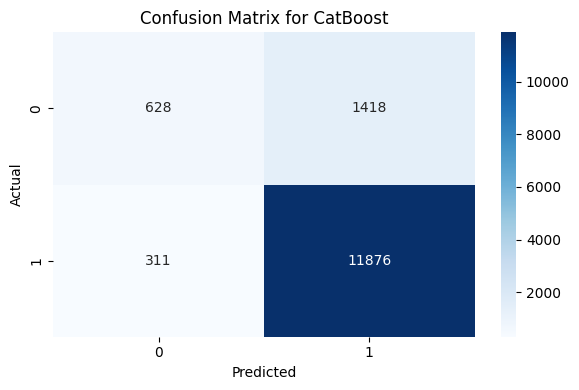


Classification Report:
               precision    recall  f1-score   support

           0     0.6688    0.3069    0.4208      2046
           1     0.8933    0.9745    0.9321     12187

    accuracy                         0.8785     14233
   macro avg     0.7811    0.6407    0.6765     14233
weighted avg     0.8611    0.8785    0.8586     14233



In [ ]:
# Predict on test set
y_pred = overall_best_model.predict(X_test_final)

# Print evaluation metrics
print("Accuracy:", accuracy_score(y_test_final, y_pred))
print("Precision (macro):", precision_score(y_test_final, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test_final, y_pred, average='macro'))
print("F1 Score (macro):", f1_score(y_test_final, y_pred, average='macro'))

# Confusion Matrix
cm = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix for {overall_best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_test_final, y_pred, digits=4))

#### Export Model

In [ ]:
import pickle
# Save model
final_model = overall_best_model
with open("/content/drive/My Drive/Colab Notebooks/data/model_ori_data.pkl", "wb") as f:
    pickle.dump(final_model, f)

#### XAI Analysis

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import Markdown

In [ ]:
# Load model
import pickle

with open("/content/drive/My Drive/Colab Notebooks/data/model_ori_data.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [ ]:
explainer = shap.TreeExplainer(loaded_model)  # assign to an explainer

In [ ]:
# X_test_final is a DataFrame
shap_values = explainer.shap_values(X_test_final)

# Sometimes shap_values is a list of two arrays
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]  # positive class
else:
    shap_values_to_plot = shap_values     # already 2D

Visualise the bar plot for ranking important features.

In [ ]:
def plot_shap_bar(shap_values, X, top_n=10, class_idx=1, model_name="Model", save=False):
    """
    Plot ranked SHAP bar plot for tree-based models.

    Parameters:
        shap_values : SHAP values (numpy array or list from TreeExplainer)
        X : pd.DataFrame, features used to compute SHAP
        top_n : int, number of top features to display
        class_idx : int, class index to select (for binary/multi-class)
        model_name : str, title of the plot
    Returns:
        shap_df : pd.DataFrame with mean_abs_shap per feature
    """

    # Handle list output (binary/multi-class)
    if isinstance(shap_values, list):
        shap_values_to_use = shap_values[class_idx]
    else:
        shap_values_to_use = shap_values

    # Flatten if 3D (n_samples, n_features, n_classes)
    if len(shap_values_to_use.shape) > 2:
        shap_values_to_use = shap_values_to_use[:, :, class_idx]

    # Compute mean absolute SHAP values
    mean_abs_shap = np.abs(shap_values_to_use).mean(axis=0)

    # Create DataFrame and select top features
    shap_df = pd.DataFrame({
        "feature": X.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values(by="mean_abs_shap", ascending=False)

    # Normalize for visualization only
    shap_df['scaled_shap'] = shap_df['mean_abs_shap'] / shap_df['mean_abs_shap'].max()
    top_features = shap_df.head(top_n)

    # Plot bar chart
    plt.figure(figsize=(8,5))
    bars = plt.barh(top_features['feature'][::-1], top_features['scaled_shap'][::-1], color='skyblue')
    bars[-1].set_color('dodgerblue')
    plt.xlabel("Scaled Mean |SHAP value|")
    plt.title(f"{model_name} Classifier - Top {top_n} \nFeature Importance")
    if save:
      plt.savefig("/content/drive/My Drive/Colab Notebooks/data/shap_bar.pdf", format="pdf")
    plt.show()

    return shap_df

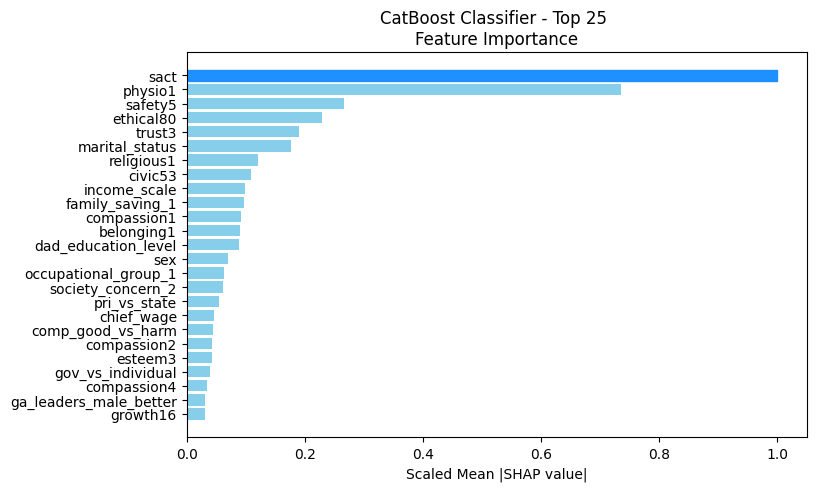

In [ ]:
# Bar plot for feature importance
display_feature = 25
overall_best_model_name = 'CatBoost'
shap_df = plot_shap_bar(shap_values, X_test_final,top_n=display_feature, model_name=overall_best_model_name, save=True)

In [ ]:
shap_values_exp = shap.Explanation(
    values=shap_values,  # the SHAP values
    data=X_test_final,                    # your original input data
    feature_names=X_test_final.columns if hasattr(X_test_final, "columns") else None
)

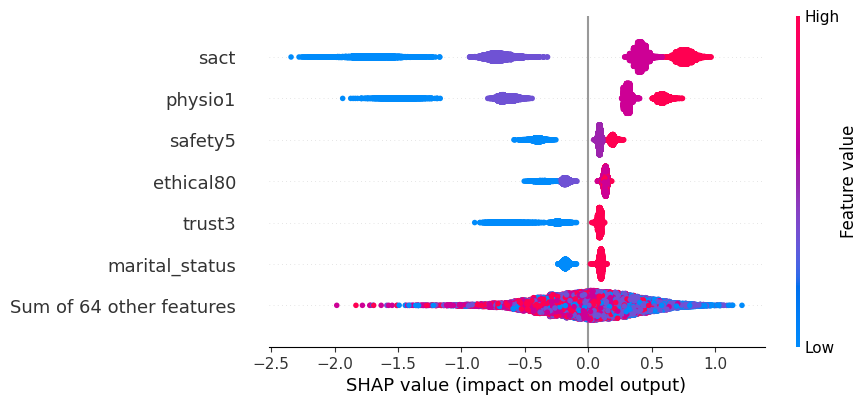

In [ ]:
# Compute mean absolute SHAP values
mean_abs = np.abs(shap_values).mean(axis=0)

# Get indices of features sorted ascending (so largest at bottom in beeswarm)
order = np.argsort(mean_abs)

shap.plots.beeswarm(shap_values_exp, max_display=7)

Create formula to calculate Happiness Index.

In [ ]:
def calculate_shap_weights(shap_values_df, top_n=3):
    """
    Calculate normalized weights based on mean absolute SHAP values.

    Returns:
        weights_normalised : dict of top features with weights summing to 1
    """
    # Compute weights
    shap_values_df["weight"] = shap_values_df["mean_abs_shap"] / shap_values_df["mean_abs_shap"].sum()

    # Select top N features
    top_features = shap_values_df.head(top_n)
    weights_dict = dict(zip(top_features["feature"], top_features["weight"]))

    # Normalize to sum exactly 1
    total = sum(weights_dict.values())
    weights_normalised = {k: round(v/total, 2) for k, v in weights_dict.items()}

    return weights_normalised


In [ ]:
weights_normalised = calculate_shap_weights(shap_df, top_n=5)

print(weights_normalised)

{'sact': 0.41, 'physio1': 0.3, 'safety5': 0.11, 'ethical80': 0.09, 'trust3': 0.08}


Normalise weights.

#### *Final Formula (Scaled to 0-100):*

In [ ]:
# latex + python dynamic formula visualisation
terms = []
for var, weight in weights_normalised.items():
    # Split letters and trailing digits, only put digits together in one subscript
    import re
    match = re.match(r"([a-zA-Z]+)(\d+)", var)
    if match:
        name, digits = match.groups()
        var_latex = f"{name}_{{{digits}}}"
    else:
        var_latex = var
    terms.append(f"{weight:.2f} \\cdot {var_latex}")

h_index_expr = ' + '.join(terms)

h_index_latex = f"""
*Happiness Index:*
$$
H_{{I}} = {h_index_expr}
$$

*Happiness Score:*
$$
H_{{I,100}} = 100 \\times \\frac{{ H_{{I}} - H_{{min}} }}{{ H_{{max}} - H_{{min}} }}
$$
"""

Markdown(h_index_latex)


*Happiness Index:*
$$
H_{I} = 0.41 \cdot sact + 0.30 \cdot physio_{1} + 0.11 \cdot safety_{5} + 0.09 \cdot ethical_{80} + 0.08 \cdot trust_{3}
$$

*Happiness Score:*
$$
H_{I,100} = 100 \times \frac{ H_{I} - H_{min} }{ H_{max} - H_{min} }
$$


In [ ]:
def plot_shap_by_income(shap_values, X_test, income_column='income_scale', top_n = 7, save=False):
    """
    Plots a grouped bar chart showing SHAP importance for each income level.

    Parameters:
    - shap_values: The SHAP values array (from explainer.shap_values(X_test))
    - X_test: The dataframe used for testing
    - income_column: The name of your ordinal income column (1-5)
    """

    # 1. Create a dataframe of absolute SHAP values
    # If binary classification, shap_values might be a list; take the second index [1]
    if isinstance(shap_values, list):
        shap_data = pd.DataFrame(np.abs(shap_values[1]), columns=X_test.columns)
    else:
        shap_data = pd.DataFrame(np.abs(shap_values), columns=X_test.columns)

    # 2. Add the income column to this SHAP dataframe to group by it
    shap_data['Income_Level'] = X_test[income_column].values

    # 3. Melt the dataframe for plotting (Long-form)
    melted_shap = shap_data.melt(id_vars='Income_Level', var_name='Feature', value_name='Mean_Abs_SHAP')

    # 4. Group by Income and Feature to get the mean importance
    grouped_shap = melted_shap.groupby(['Income_Level', 'Feature']).mean().reset_index()

    # 5. Filter for the Top n features (based on overall importance) to keep it clean
    top_n_features = grouped_shap.groupby('Feature')['Mean_Abs_SHAP'].mean().nlargest(top_n).index
    final_plot_df = grouped_shap[grouped_shap['Feature'].isin(top_n_features)]

    # 6. Plotting
    plt.figure(figsize=(12, 8))
    sns.barplot(data=final_plot_df, x='Mean_Abs_SHAP', y='Feature', hue='Income_Level', palette='viridis')

    plt.title('SHAP Feature Importance Classified by Income Scale (1-5)', fontsize=15)
    plt.xlabel('Mean |SHAP Value| (Impact on Model Output)')
    plt.ylabel('Top Features')
    plt.legend(title='Income Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    if save:
        plt.savefig("/content/drive/My Drive/Colab Notebooks/data/shap_by_income.pdf", format="pdf")
    plt.show()

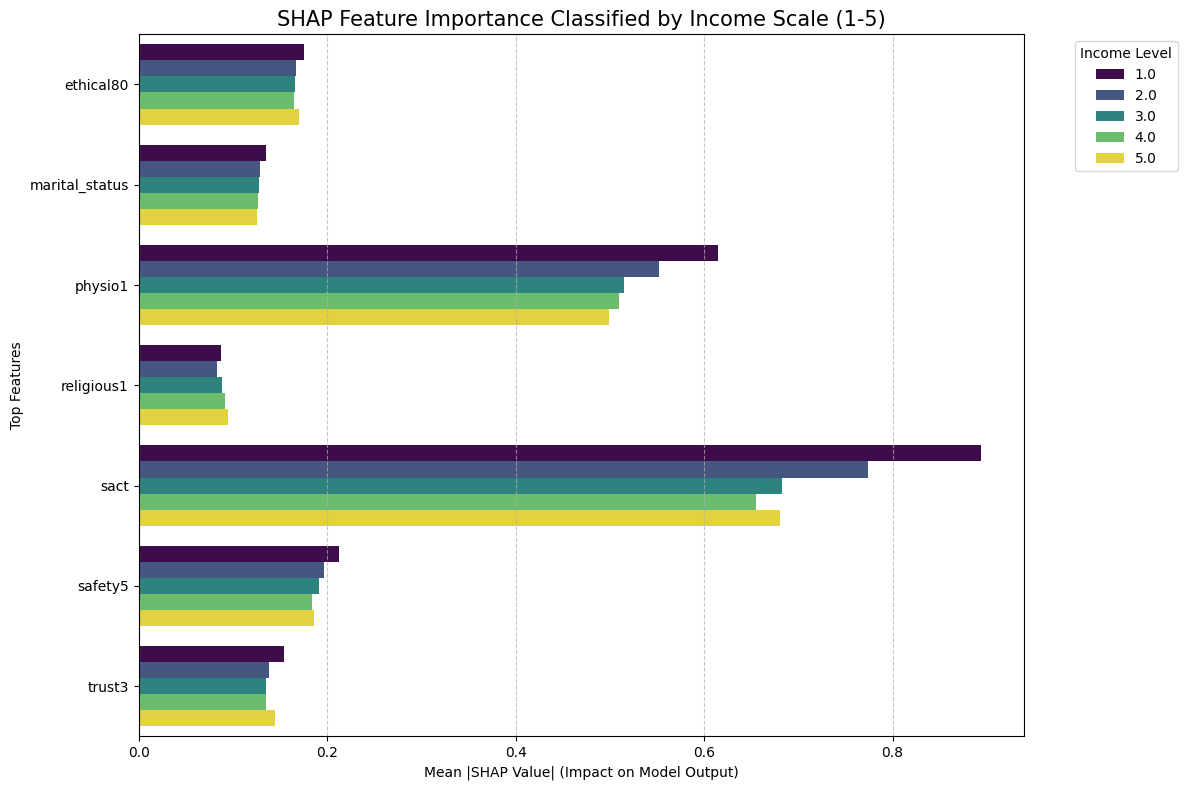

In [ ]:
plot_shap_by_income(shap_values, X_test_final, income_column='income_scale', top_n = 7,save=True)

In [ ]:
vars = list(weights_normalised.keys())
show_var_details(vars, variable_table, var_ques=True)

"sact" Q49
Question: Satisfaction with your life
----------
"physio1" Q47P
Question: State of health (subjective)
----------
"safety5" Q131P
Question: Secure in neighborhood
----------
"trust3" Q58P
Question: How much you trust: Your family
----------
"ethical80" Q253P
Question: Respect for individual human rights nowadays
----------
